# Loss functions

> A set of custom loss functions

In [ ]:
#| default_exp losses

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *
from torch import randn, randint

In [ ]:
#| export

# =================================
# Scientific
# =================================
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# =================================
# PyTorch
# =================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor as torchTensor
from torch.nn.modules.loss import _Loss

# =================================
# MONAI
# =================================
import monai.losses as ml
from monai.utils import LossReduction, ensure_tuple_rep

# =================================
# fastai
# =================================
from fastai.vision.all import (
    Any,
    noops,
    BaseLoss as fastaiBaseLoss,
)

import fastai.losses as fl

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *

## Base Functions

In [ ]:
#| export

LOSS_BACKENDS = {}

def register_loss_backend(name):
    """Register a loss backend."""
    def decorator(backend):
        if name in LOSS_BACKENDS:
            raise ValueError(f"Loss backend already registered: {name}")
        LOSS_BACKENDS[name] = backend
        return backend

    return decorator

In [ ]:
#| export

class BioLoss:
    """
    Backend-independent interface for loss functions in bioMONAI.

    ``BioLoss`` defines a canonical loss together with its default activation
    and decoding functions. A loss can optionally provide a backend-specific
    implementation through attributes such as ``_torch``, ``_monai``,
    ``_fastai``, or ``_keras``.

    When an explicit backend implementation is available, it is instantiated
    directly and the backend adapter is skipped. Otherwise, ``_default`` is
    passed to the registered backend adapter, which adapts the loss to the
    selected framework.

    Parameters
    ----------
    backend : str, default="monai"
        Backend used to instantiate the loss.
    *args
        Positional arguments passed to the loss implementation.
    **kwargs
        Keyword arguments passed to the loss implementation.

    Attributes
    ----------
    _default : callable
        Default loss implementation.
    _<backend> : callable, optional
        Backend-specific loss implementation. For example, ``_torch`` or
        ``_fastai``. When present, this implementation takes precedence over
        ``_default`` and is instantiated directly.
    activation : callable
        Converts raw model outputs into the prediction space associated with
        the loss. Defaults to ``noops``.
    decodes : callable
        Converts predictions into their decoded representation. Defaults to
        ``noops``.
    """

    _default = None

    activation = noops
    decodes = noops

    def __new__(cls, *args, backend="monai", **kwargs):
        """
        Instantiate the loss using the requested backend.
        """
        backend = cls._validate_backend(backend)

        # Use an explicit backend implementation when available.
        backend_loss = getattr(cls, f"_{backend}", None)

        if backend_loss is not None:
            return backend_loss(*args, **kwargs)

        # Otherwise let the backend adapter wrap/adapt the default loss.
        backend_cls = cls._get_backend(backend)

        return backend_cls.create(
            cls,
            *args,
            **kwargs,
        )

    @staticmethod
    def _validate_backend(backend):
        """Validate and normalize a backend name."""
        if not isinstance(backend, str) or not backend.strip():
            raise ValueError("backend must be a non-empty string")
        return backend.lower()

    @classmethod
    def _get_backend(cls, backend):
        """
        Return the registered backend adapter for ``backend``.
        """
        try:
            return LOSS_BACKENDS[backend]
        except KeyError:
            raise ValueError(
                f"Unknown loss backend '{backend}'. "
                f"Available backends: {list(LOSS_BACKENDS)}"
            ) from None

### Backend wrappers

In [ ]:
#| export

class LossBackend:
    """
    Base backend adapter for bioMONAI losses.

    Backend adapters translate a canonical bioMONAI loss definition into
    the loss implementation required by a specific framework.

    By default, the canonical ``_default`` loss implementation is
    instantiated directly. Backends that require additional adaptation
    can override :meth:`create`.

    Parameters
    ----------
    loss_cls : type
        ``BioLoss`` subclass defining the loss implementation.
    *args
        Positional arguments passed to the loss constructor.
    **kwargs
        Keyword arguments passed to the loss constructor.

    Examples
    --------
    A backend that uses the default implementation directly can simply
    inherit from ``LossBackend``::

        class TorchLossBackend(LossBackend):
            pass

    A backend requiring adaptation can override ``create``::

        class FastaiLossBackend(LossBackend):
            @classmethod
            def create(cls, loss_cls, *args, **kwargs):
                return BaseLoss(loss_cls._default, *args, **kwargs)
    """

    @classmethod
    def create(cls, loss_cls, *args, **kwargs):
        """
        Instantiate the default loss implementation.

        Parameters
        ----------
        loss_cls : type
            ``BioLoss`` subclass whose ``_default`` implementation should
            be instantiated.
        *args
            Positional arguments passed to the loss.
        **kwargs
            Keyword arguments passed to the loss.

        Returns
        -------
        Any
            Instantiated loss.
        """
        if loss_cls._default is None:
            raise ValueError(
                f"{loss_cls.__name__} does not define a '_default' loss "
                "implementation."
            )

        return loss_cls._default(*args, **kwargs)

In [ ]:
#| export
@register_loss_backend("torch")
class TorchLossBackend(LossBackend):
    """Backend adapter for PyTorch losses."""
    pass

@register_loss_backend("monai")
class MonaiLossBackend(LossBackend):
    """Backend adapter for MONAI losses."""
    pass

@register_loss_backend("keras")
class KerasLossBackend(LossBackend):
    """Backend adapter for Keras losses."""
    pass

@register_loss_backend("ignite")
class IgniteLossBackend(LossBackend):
    """Backend adapter for Ignite losses."""
    pass

@register_loss_backend("fastai")
class FastaiLossBackend(LossBackend):
    """
    Backend adapter for fastai losses.

    The default PyTorch-compatible loss is wrapped with fastai's
    ``BaseLoss``. The canonical loss's ``activation`` and ``decodes``
    functions are then exposed by the resulting fastai loss.
    """

    @classmethod
    def create(cls, loss_cls, *args, **kwargs):
        loss = fastaiBaseLoss(
            loss_cls._default,
            *args,
            **kwargs,
        )

        loss.activation = loss_cls.activation
        loss.decodes = loss_cls.decodes

        return loss

## Regression


In [ ]:
#| export

class MSELoss(BioLoss):
    """
    Mean Squared Error (MSE) loss.

    Computes the average squared difference between the predicted values
    and the target values. MSE penalizes larger errors more strongly than
    smaller errors because the residual is squared.

    The element-wise MSE is defined as:

        L_i = (input_i - target_i)^2

    For ``reduction="mean"``, the loss is:

        L = 1/N * sum_i (input_i - target_i)^2

    For ``reduction="sum"``, the loss is:

        L = sum_i (input_i - target_i)^2

    For ``reduction="none"``, the unreduced element-wise squared errors
    are returned.

    MSE is commonly used for regression and image restoration tasks,
    where it measures the squared Euclidean distance between predicted
    and target values.

    Parameters
    ----------
    reduction : str, optional
        Specifies the reduction applied to the output:

        - ``"mean"``: average all element-wise squared errors.
        - ``"sum"``: sum all element-wise squared errors.
        - ``"none"``: return the element-wise squared errors.

        Default is ``"mean"``.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`torch.nn.MSELoss` and therefore retains the same behavior
    and API as the underlying PyTorch implementation.

    Examples
    --------
    >>> loss = MSELoss()
    >>> input = torch.tensor([1.0, 2.0, 4.0])
    >>> target = torch.tensor([1.0, 3.0, 2.0])
    >>> loss(input, target)
    tensor(1.6667)
    """

    _default = nn.MSELoss
    _torch = nn.MSELoss
    _fastai = fl.MSELossFlat


In [ ]:
#| export

class MAELoss(BioLoss):
    """
    Mean Absolute Error (MAE) loss.

    Computes the average absolute difference between the predicted values
    and the target values. Unlike Mean Squared Error (MSE), MAE penalizes
    errors linearly, making it less sensitive to large outliers.

    The element-wise MAE is defined as:

        L_i = |input_i - target_i|

    For ``reduction="mean"``, the loss is:

        L = 1/N * sum_i |input_i - target_i|

    For ``reduction="sum"``, the loss is:

        L = sum_i |input_i - target_i|

    For ``reduction="none"``, the unreduced element-wise absolute errors
    are returned.

    MAE is commonly used for regression, image restoration, and
    reconstruction tasks where robustness to large errors is desirable.

    Parameters
    ----------
    reduction : str, optional
        Specifies the reduction applied to the output:

        - ``"mean"``: average all element-wise absolute errors.
        - ``"sum"``: sum all element-wise absolute errors.
        - ``"none"``: return the element-wise absolute errors.

        Default is ``"mean"``.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`torch.nn.L1Loss` and therefore retains the same behavior
    and API as the underlying PyTorch implementation.

    Examples
    --------
    >>> loss = MAELoss()
    >>> input = torch.tensor([1.0, 2.0, 4.0])
    >>> target = torch.tensor([1.0, 3.0, 2.0])
    >>> loss(input, target)
    tensor(1.0000)
    """

    _default = nn.L1Loss
    _torch = nn.L1Loss
    _fastai = fl.L1LossFlat

In [ ]:
#| export

class SmoothMAELoss(BioLoss):
    """
    Smooth L1 loss for robust regression.

    Smooth L1 combines a quadratic region around zero error with a
    linear region for larger errors.

    For error ``e = x-y`` and transition parameter ``beta``:

    .. math::

        \\mathcal{L}(e) =
        \\begin{cases}
        \\frac{1}{2}\\frac{e^2}{\\beta},
        & |e| < \\beta \\\\
        |e|-\\frac{1}{2}\\beta,
        & |e| \\geq \\beta
        \\end{cases}

    The quadratic region provides smooth gradients near zero, while
    the linear region makes the loss less sensitive to outliers than
    MSE.

    Args:
        beta: Size of the quadratic region.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    _default = nn.SmoothL1Loss
    _torch = nn.SmoothL1Loss


In [ ]:
#| export

class SSIMLoss(BioLoss):
    """
    Structural Similarity Index Measure (SSIM) loss.

    SSIM is a perceptual image-similarity measure that compares local
    luminance, contrast, and structural information between an input
    image and a target image. It is particularly useful for image
    reconstruction and restoration tasks where perceptual structure is
    more important than purely pixel-wise differences.

    The SSIM index between two local image regions is defined as:

        SSIM(x, y) =
            ((2 * μ_x * μ_y + C1)
             * (2 * σ_xy + C2))
            /
            ((μ_x² + μ_y² + C1)
             * (σ_x² + σ_y² + C2))

    where:

        μ_x, μ_y
            Local means of the input and target.

        σ_x², σ_y²
            Local variances of the input and target.

        σ_xy
            Local covariance between the input and target.

        C1, C2
            Stabilizing constants that prevent numerical instability.

    The SSIM loss is defined as:

        L_SSIM = 1 - SSIM(x, y)

    The implementation uses MONAI's SSIM formulation, including its
    configurable spatial dimensions, Gaussian filtering, kernel size,
    and reduction behavior.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions of the input images. Typically
        ``2`` for 2D images or ``3`` for volumetric images.
    data_range : float
        Dynamic range of the input data.
    kernel_sigma : float or sequence of float
        Standard deviation of the Gaussian kernel used to compute
        local statistics.
    kernel_size : int or sequence of int
        Size of the Gaussian kernel.
    win_size : int or sequence of int, optional
        Alternative window-size parameter supported by MONAI's
        implementation.
    k1 : float
        Constant used to calculate ``C1``.
    k2 : float
        Constant used to calculate ``C2``.
    reduction : str
        Specifies the reduction applied to the output:

        - ``"mean"``: average the loss.
        - ``"sum"``: sum the loss.
        - ``"none"``: return the unreduced loss.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.SSIMLoss`. The underlying MONAI implementation
    is retained, so its full API and behavior are preserved.

    SSIM is complementary to pixel-wise losses such as :class:`MSELoss`
    and :class:`MAELoss`: two images can have relatively similar pixel
    values while differing structurally, or have small structural
    differences despite relatively large pixel-wise errors.

    Examples
    --------
    >>> loss = SSIMLoss(spatial_dims=2)
    >>> input = torch.rand(1, 1, 64, 64)
    >>> target = torch.rand(1, 1, 64, 64)
    >>> value = loss(input, target)
    """

    _default = ml.SSIMLoss
    _monai = ml.SSIMLoss

In [ ]:
#| export

class PatchAdversarialLoss(BioLoss):
    """
    Patch-based adversarial loss for generative adversarial networks (GANs).

    Computes an adversarial loss from the patch-level predictions produced
    by a discriminator. Unlike a conventional discriminator that produces
    a single scalar prediction for an entire image, a patch discriminator
    produces a spatial map of predictions, where each value corresponds to
    the realism of a local image patch.

    This type of loss is commonly used in image-to-image translation,
    image synthesis, and image restoration, where encouraging realistic
    local structures can improve the visual quality of generated images.

    For a discriminator prediction ``D(x)``, the adversarial objective
    depends on whether the prediction corresponds to a real or generated
    image. A generic binary adversarial formulation can be written as:

        L_D = L_adv(D(x_real), real)
            + L_adv(D(x_fake), fake)

    where ``L_adv`` is the selected adversarial loss function.

    For a generator, the adversarial objective encourages the discriminator
    to classify generated patches as real:

        L_G = L_adv(D(x_fake), real)

    The exact mathematical formulation depends on the adversarial loss
    mode selected by MONAI, such as least-squares or hinge-style losses.

    Parameters
    ----------
    criterion : str
        Adversarial loss criterion used to evaluate discriminator
        predictions. The available criteria depend on the underlying
        MONAI implementation.
    reduction : str
        Specifies how the patch-wise losses are reduced. Supported
        values depend on the underlying MONAI implementation.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.PatchAdversarialLoss`. The underlying MONAI
    implementation is retained, including its handling of patch-based
    discriminator outputs and supported adversarial criteria.

    Because the discriminator produces multiple patch predictions,
    the loss is generally computed over the discriminator output map
    rather than a single scalar prediction.

    Examples
    --------
    >>> loss = PatchAdversarialLoss(criterion="least_squares")
    >>> discriminator_output = torch.randn(2, 1, 16, 16)
    >>> value = loss(discriminator_output, target_is_real=True)

    References
    ----------
    Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley,
    D., Ozair, S., Courville, A., & Bengio, Y. (2014).
    Generative Adversarial Nets. Advances in Neural Information
    Processing Systems, 27.

    Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017).
    Image-to-Image Translation with Conditional Adversarial Networks.
    Proceedings of the IEEE Conference on Computer Vision and Pattern
    Recognition, 1125-1134.
    """

    _default = ml.PatchAdversarialLoss
    _monai = ml.PatchAdversarialLoss

In [ ]:
#| export

class PerceptualLoss(BioLoss):
    """
    Perceptual loss based on deep feature representations.

    Compares an input image and a target image using feature
    representations extracted from a pretrained neural network rather
    than comparing the images only at the pixel level.

    The underlying network extracts features at one or more layers.
    The perceptual loss measures the discrepancy between the
    corresponding feature representations:

        L_perceptual =
            sum_l w_l * D(phi_l(input), phi_l(target))

    where:

        phi_l
            Feature representation extracted from layer ``l`` of the
            pretrained network.

        w_l
            Weight assigned to feature layer ``l``.

        D
            Distance function used to compare the feature maps.

    By comparing high-level feature representations, perceptual loss can
    encourage generated or reconstructed images to preserve semantic
    structures and visual characteristics that may not be well captured
    by pixel-wise losses such as MSE or MAE.

    It is commonly used for image synthesis, super-resolution,
    reconstruction, image restoration, and generative models.

    Parameters
    ----------
    network : torch.nn.Module
        Neural network used to extract perceptual features. Typically a
        pretrained classification or feature-extraction network.
    network_type : str
        Type of network architecture used for feature extraction.
    feature_layers : sequence of int
        Layers from which feature representations are extracted.
    is_fake_3d : bool
        Whether the inputs should be treated as fake 3D data when using
        a 2D feature-extraction network.
    pretrained : bool
        Whether to use pretrained network weights.
    spatial_dims : int
        Number of spatial dimensions of the input data.
    reduction : str
        Reduction applied to the feature-space losses.

    Notes
    -----
    This class is a thin bioMONAI wrapper around
    :class:`monai.losses.PerceptualLoss`. The underlying MONAI
    implementation is retained, including its feature-extraction
    network, layer selection, and dimensionality handling.

    Perceptual loss is generally complementary to pixel-wise losses.
    Pixel losses directly penalize intensity differences, whereas
    perceptual loss penalizes differences in learned feature space.
    Combining them can therefore provide both pixel-level fidelity and
    preservation of higher-level image structure.

    Examples
    --------
    >>> loss = PerceptualLoss(
    ...     spatial_dims=2,
    ...     network_type="alex",
    ... )
    >>> input = torch.rand(1, 3, 128, 128)
    >>> target = torch.rand(1, 3, 128, 128)
    >>> value = loss(input, target)

    References
    ----------
    Johnson, J., Alahi, A., & Fei-Fei, L. (2016).
    Perceptual Losses for Real-Time Style Transfer and Super-Resolution.
    European Conference on Computer Vision, 694-711.

    Zhang, R., Isola, P., Efros, A. A., Shechtman, E., & Wang, O. (2018).
    The Unreasonable Effectiveness of Deep Features as a Perceptual
    Metric. Proceedings of the IEEE Conference on Computer Vision and
    Pattern Recognition, 586-595.
    """

    _default = ml.PerceptualLoss
    _monai = ml.PerceptualLoss

In [ ]:
#| export

class JukeboxLoss(BioLoss):
    """
    Jukebox loss for vector-quantized hierarchical autoencoders.

    This loss is used in Jukebox-style architectures with multiple
    vector-quantization levels. It measures the discrepancy between the
    encoder outputs and their corresponding quantized representations,
    encouraging the encoder to produce representations that are well
    represented by the learned codebook.

    For a quantization level ``l``, the commitment/codebook loss can be
    expressed conceptually as:

        L_l = ||sg[z_e] - z_q||²
              + β ||z_e - sg[z_q]||²

    where:

    - ``z_e`` is the encoder representation,
    - ``z_q`` is the corresponding quantized/codebook representation,
    - ``sg[·]`` denotes stop-gradient,
    - ``β`` controls the encoder commitment term.

    For multiple quantization levels, the total loss is typically a
    weighted combination of the losses associated with the different
    levels:

        L = Σ_l w_l L_l

    The exact computation depends on the inputs and configuration of the
    underlying MONAI implementation.

    Jukebox-style losses are particularly useful for models that learn
    discrete latent representations through vector quantization, such
    as hierarchical VQ-VAE architectures.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.JukeboxLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.JukeboxLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.JukeboxLoss`. The constructor and forward
    behavior are inherited unchanged from MONAI, ensuring compatibility
    with the installed MONAI version.

    Examples
    --------
    >>> loss = JukeboxLoss(...)
    >>> value = loss(input, target)

    References
    ----------
    Dhariwal, P., et al. (2020).
    Jukebox: A Generative Model for Music.
    arXiv:2005.00341.
    """
    _default = ml.JukeboxLoss
    _monai = ml.JukeboxLoss

In [ ]:
#| export

class HuberLoss(BioLoss):
    """
    Huber loss for robust regression.

    The Huber loss behaves quadratically for small residuals and
    linearly for large residuals.

    For residual ``e = x-y`` and threshold ``delta``:

    .. math::

        \\mathcal{L}(e) =
        \\begin{cases}
        \\frac{1}{2}e^2,
        & |e| \\leq \\delta \\\\
        \\delta(|e|-\\frac{1}{2}\\delta),
        & |e| > \\delta
        \\end{cases}

    It therefore combines the smooth behavior of MSE near the optimum
    with the robustness of L1 loss for outliers.

    Args:
        delta: Transition point between quadratic and linear behavior.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    _default = nn.HuberLoss
    _torch = nn.HuberLoss


### Probabilistic regression

In [ ]:
#| export

class GaussianNLLLoss(BioLoss):
    """
    Gaussian negative log-likelihood loss.

    Models the target as a Gaussian distribution with predicted mean
    ``mu`` and variance ``sigma^2``.

    Ignoring the constant terms when appropriate, the negative
    log-likelihood is:

    .. math::

        \\mathcal{L}
        =
        \\frac{1}{2}
        \\left[
        \\log(\\sigma^2)
        +
        \\frac{(y-\\mu)^2}{\\sigma^2}
        \\right]

    Unlike ordinary MSE, this loss allows the model to predict both
    the expected value and its uncertainty.

    Args:
        full: Include the constant ``log(2*pi)`` term.
        eps: Minimum variance used for numerical stability.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.

    Expected inputs:

        ``input`` contains the predicted mean ``mu``.
        ``var`` contains the predicted variance.
    """
    _default = nn.GaussianNLLLoss
    _torch = nn.GaussianNLLLoss

In [ ]:
#| export

class PoissonNLLLoss(BioLoss):
    """
    Poisson negative log-likelihood loss.

    This loss is appropriate for count-valued observations modeled
    using a Poisson distribution.

    For predicted mean ``lambda`` and target ``y``:

    .. math::

        \\mathcal{L}
        =
        \\lambda - y\\log(\\lambda) + \\log(y!)

    When ``log_input=True``, the model is assumed to predict
    ``log(lambda)`` and the implementation evaluates the equivalent
    expression in a numerically stable form.

    Args:
        log_input: If ``True``, input represents ``log(lambda)``.
        full: Include the Stirling approximation of ``log(y!)``.
        eps: Small value used to avoid ``log(0)``.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    _default = nn.PoissonNLLLoss
    _torch = nn.PoissonNLLLoss

### Fourier Ring Correlation

In [ ]:
#| export
def radial_mask(r, cx, cy, sx, sy, delta=1):
    """
    Create a circular mask centered in the frequency domain.

    Parameters
    ----------
    shape : tuple[int, int]
        Spatial shape ``(H, W)`` of the Fourier domain.
    radius : float
        Radius of the circular region in pixels.

    Returns
    -------
    torch.Tensor
        Boolean mask with ``True`` inside the specified radius and
        ``False`` outside.

    Notes
    -----
    The mask is used to isolate Fourier coefficients within a
    particular spatial-frequency region.
    """

    x = np.arange(sx)
    y = np.arange(sy)

    xx, yy = np.meshgrid(x, y, indexing="xy")

    dist2 = (xx - cx) ** 2 + (yy - cy) ** 2

    inner = dist2 > (r[0] ** 2)
    outer = dist2 <= ((r[0] + delta) ** 2)

    return inner & outer

In [ ]:
#| export
def get_fourier_ring_correlations(image1, image2):
    """
    Compute Fourier Ring Correlation (FRC) between two images.

    FRC is a frequency-domain measure of the similarity between two
    images. Instead of comparing pixels directly in the spatial domain,
    FRC compares their Fourier transforms over concentric rings of
    increasing spatial frequency.

    For each Fourier ring, the complex Fourier coefficients of the two
    images are compared using their normalized cross-correlation:

    .. math::

        \\mathrm{FRC}(r) =
        \\frac{
            \\sum_{k \\in r} F_1(k) F_2(k)^*
        }{
            \\sqrt{
                \\sum_{k \\in r} |F_1(k)|^2
                \\sum_{k \\in r} |F_2(k)|^2
            }
        }

    where ``F_1`` and ``F_2`` are the Fourier transforms of the two
    images, ``*`` denotes complex conjugation, and ``r`` denotes a
    Fourier ring.

    The resulting FRC curve describes how consistently the two images
    contain the same spatial-frequency information. Values close to
    ``1`` indicate strong agreement at a given frequency, whereas
    values close to ``0`` indicate little or no correlation.

    Low spatial frequencies correspond to coarse image structures,
    while high spatial frequencies correspond to increasingly fine
    structures and details. Consequently, the decay of the FRC curve
    toward high frequencies can be used to characterize the effective
    spatial resolution of an imaging or reconstruction method.

    Parameters
    ----------
    image1 : torch.Tensor
        First image. Must have the same spatial dimensions as
        ``image2``.
    image2 : torch.Tensor
        Second image. Must have the same spatial dimensions as
        ``image1``.
    num_rings : int, default=50
        Number of concentric Fourier rings used to estimate the FRC
        curve.

    Returns
    -------
    torch.Tensor
        One-dimensional tensor containing the FRC value for each
        Fourier ring.

    Notes
    -----
    FRC is commonly used in microscopy to estimate spatial resolution,
    particularly when comparing independent image acquisitions or
    reconstructions. In this context, two images should ideally
    represent independent measurements of the same underlying sample;
    otherwise, shared noise or processing artifacts can artificially
    increase the correlation.

    The Fourier transform is shifted so that the zero spatial frequency
    is at the center of the Fourier domain before the concentric rings
    are evaluated.

    See Also
    --------
    FRCutoff
        Estimate a resolution cutoff from the FRC curve.
    """

    device = image1.device

    H, W = image1.shape[-2:]

    freq_nyq = min(H, W) // 2

    radii = torch.arange(freq_nyq, device=device).float()

    spatial_freq = radii / freq_nyq

    radial_masks = torch.stack([
        torch.tensor(
            radial_mask(
                r=[int(r)],
                cx=W // 2,
                cy=H // 2,
                sx=W,
                sy=H,
                delta=1,
            ),
            device=device,
            dtype=torch.bool,
        )
        for r in radii
    ])

    fft1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft2 = torch.fft.fftshift(torch.fft.fft2(image2))

    fft1 = fft1.unsqueeze(0).expand(freq_nyq, -1, -1)
    fft2 = fft2.unsqueeze(0).expand(freq_nyq, -1, -1)

    t1 = fft1 * radial_masks
    t2 = fft2 * radial_masks

    numerator = torch.abs(
        torch.real((t1 * t2.conj()).sum(dim=(-2, -1)))
    )

    denom = torch.sqrt(
        (t1.abs() ** 2).sum(dim=(-2, -1)) *
        (t2.abs() ** 2).sum(dim=(-2, -1)) +
        1e-8
    )

    frc = numerator / denom

    frc = torch.nan_to_num(frc, nan=0.0, posinf=0.0, neginf=0.0)

    return frc, spatial_freq

In [ ]:
#| export
def FCRCutoff(
    image1,
    image2,
    threshold=1 / 7,
    smoothing=True,
    window_length=20,
    polyorder=1,
    plot=False,
):
    """
    Determine the spatial-frequency cutoff from a Fourier Ring
    Correlation (FRC) curve.

    FRC measures the agreement between two images as a function of
    spatial frequency. At low frequencies, corresponding to large-scale
    structures, the two images typically show strong agreement and the
    FRC is high. As spatial frequency increases, agreement generally
    decreases because progressively finer structures are less reliably
    reproduced.

    The FRC curve is optionally smoothed before determining the cutoff.
    The cutoff is defined as the first spatial frequency at which the
    smoothed FRC curve falls below the specified threshold.

    Parameters
    ----------
    image1, image2 : array-like or torch.Tensor
        Images to compare.
    threshold : float, default=1/7
        FRC threshold used to determine the cutoff frequency. The
        ``1/7`` criterion is commonly used for resolution estimation,
        although other criteria can be appropriate depending on the
        application and experimental setup.
    smoothing : bool, default=True
        Whether to smooth the FRC curve before determining the cutoff.
    window_length : int, default=7
        Length of the smoothing window used by the Savitzky-Golay filter.
        Must be an odd integer and larger than ``polyorder``.
    polyorder : int, default=2
        Polynomial order used by the Savitzky-Golay filter.
    plot : bool, default=False
        If ``True``, plot both the original and smoothed FRC curves.

    Returns
    -------
    float
        Spatial-frequency cutoff.

    Notes
    -----
    Smoothing is useful because FRC curves can exhibit local fluctuations
    that cause a direct threshold crossing to occur prematurely. The
    Savitzky-Golay filter reduces these fluctuations while preserving the
    general shape and slope of the FRC curve.

    The cutoff should be interpreted as a resolution estimate rather
    than an absolute physical limit. Its reliability depends on how
    the two images were generated, whether they constitute independent
    measurements, preprocessing, sampling, and the particular FRC
    criterion used.

    If the spatial frequency cutoff is ``f_c`` cycles per unit distance,
    the corresponding resolution is approximately

    .. math::

        d \\approx \\frac{1}{f_c}.
    """

    frc, freq = get_fourier_ring_correlations(image1, image2)

    frc_np = frc.detach().cpu().numpy()
    freq_np = freq.detach().cpu().numpy()

    # ---------------------------------
    # Smooth FRC curve
    # ---------------------------------
    if smoothing:
        from scipy.signal import savgol_filter

        # Make sure the window is valid for the available number of points
        n = len(frc_np)

        window = min(window_length, n if n % 2 else n - 1)

        if window <= polyorder:
            raise ValueError(
                f"window_length must be greater than polyorder. "
                f"Got window_length={window}, polyorder={polyorder}."
            )

        if window < 3:
            frc_smooth = frc_np.copy()
        else:
            frc_smooth = savgol_filter(
                frc_np,
                window_length=window,
                polyorder=polyorder,
            )
    else:
        frc_smooth = frc_np

    # ---------------------------------
    # Find threshold crossing
    # ---------------------------------
    below = frc_smooth < threshold

    if not np.any(below):
        cutoff = freq_np[-1]
    else:
        cutoff = freq_np[np.where(below)[0][0]]

    # ---------------------------------
    # Optional plotting
    # ---------------------------------
    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(6, 4))

        plt.plot(
            freq_np,
            frc_np,
            alpha=0.4,
            label="FRC",
            marker="o",
            linestyle="None",
        )

        if smoothing:
            plt.plot(
                freq_np,
                frc_smooth,
                linewidth=2,
                color="steelblue",
                label="Smoothed FRC",
            )

        plt.axhline(
            y=threshold,
            linestyle="--",
            color="maroon",
            label=f"threshold = {threshold:.3f}",
        )

        plt.axvline(
            x=cutoff,
            linestyle="--",
            color="goldenrod",
            label=f"cutoff = {cutoff:.3f}",
        )

        plt.xlabel("Spatial frequency")
        plt.ylabel("FRC")
        plt.title("Fourier Ring Correlation Cutoff")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return cutoff

In [ ]:
#| export

class _FRCLoss(_Loss):
    """
    Compute the Fourier Ring Correlation (FRC) loss.

    The FRC loss is defined as:

    ``FRC loss = 1 - mean(FRC)``

    where the Fourier Ring Correlation is computed across spatial
    frequency rings.

    Parameters
    ----------
    reduction : str, default="mean"
        Specifies the reduction applied to the output:

        - ``"none"``: no reduction is applied.
        - ``"mean"``: average the FRC loss values.
        - ``"sum"``: sum the FRC loss values.

    Notes
    -----
    The underlying Fourier Ring Correlation is computed by
    ``get_fourier_ring_correlations``. The input images must have a
    shape supported by that function.

    Examples
    --------
    Compute the FRC loss between two images::

        loss_fn = FRCLoss()
        loss = loss_fn(image1, image2)

    For batch inputs, use::

        loss_fn = FRCLoss(reduction="mean")
        loss = loss_fn(pred, target)
    """

    def __init__(
        self,
        reduction: str = "mean",
    ):
        super().__init__(reduction=reduction)

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the FRC loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted or reconstructed images.

        target : torch.Tensor
            Reference images.

        Returns
        -------
        torch.Tensor
            FRC loss. The value is ``1 - FRC``.
        """
        frc, _ = get_fourier_ring_correlations(
            input,
            target,
        )

        loss = 1.0 - frc

        if self.reduction == LossReduction.MEAN.value:
            loss = torch.mean(loss)
        elif self.reduction == LossReduction.SUM.value:
            loss = torch.sum(loss)

        return loss



class FRCLoss(BioLoss):
    """
    Loss based on Fourier Ring Correlation (FRC).

    Fourier Ring Correlation measures the similarity between two images
    in the frequency domain by comparing their Fourier coefficients
    over concentric rings of spatial frequency.

    This loss converts the FRC similarity into an optimization objective,
    so that minimizing the loss encourages the prediction to reproduce
    the target's spatial-frequency content.

    FRC is particularly useful for image restoration and reconstruction
    tasks where preservation of fine spatial detail is important. Unlike
    purely pixel-wise losses such as MSE or MAE, an FRC-based objective
    explicitly evaluates agreement across spatial frequencies. This can
    make it sensitive to the preservation or loss of high-frequency
    structures such as fine cellular features, edges, and microscopy
    details.

    Conceptually:

    .. math::

        \\mathrm{FRC}(f)
        =
        \\frac{
            \\sum_{k \\in f} F_{pred}(k) F_{target}(k)^*
        }{
            \\sqrt{
                \\sum_{k \\in f}|F_{pred}(k)|^2
                \\sum_{k \\in f}|F_{target}(k)|^2
            }
        }

    where ``f`` denotes a Fourier ring and ``*`` denotes complex
    conjugation.

    The resulting FRC curve is then reduced to a scalar loss according
    to the selected reduction strategy.

    Notes
    -----
    FRC is fundamentally a frequency-domain similarity measure. It
    therefore complements spatial-domain losses rather than directly
    replacing them. In image restoration, combining FRC with losses
    such as MSE, MAE, SSIM, or perceptual losses can provide information
    about both pixel-level accuracy and preservation of spatial detail.

    Because FRC compares Fourier representations, its interpretation
    depends on image sampling, frequency normalization, and the
    independence or statistical relationship between the compared
    images.
    """

    _default = _FRCLoss
    _torch = _FRCLoss

FRC Loss: 0.8339


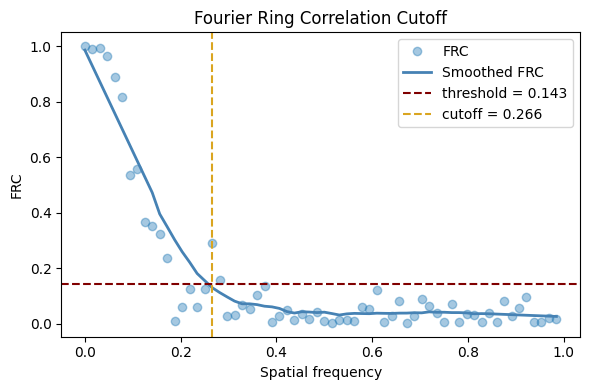

In [ ]:
def test_frc():
    """
    Simple sanity test for FRC + FRCLoss.
    """

    # ---------------------------------
    # 1. Create synthetic images
    # ---------------------------------
    size = 128

    x = torch.linspace(-1, 1, size)
    y = torch.linspace(-1, 1, size)
    xx, yy = torch.meshgrid(x, y, indexing="xy")

    # Base image: smooth Gaussian
    img1 = torch.exp(-(xx**2 + yy**2))

    # Slightly degraded version (blur + noise)
    noise = 0.05 * torch.randn_like(img1)
    img2 = torch.exp(-(xx**2 + yy**2) * 1.2) + noise

    img1 = img1.float()
    img2 = img2.float()

    # ---------------------------------
    # 2. Compute FRC
    # ---------------------------------
    frc, freq = get_fourier_ring_correlations(img1, img2)

    # ---------------------------------
    # 3. Compute loss
    # ---------------------------------
    loss = FRCLoss()(img1, img2)
    print(f"FRC Loss: {loss.item():.4f}")

    test_close(loss, 1.0 - frc.mean())

    # ---------------------------------
    # 4. Plot
    # ---------------------------------
    FCRCutoff(img1, img2, threshold=1/7, plot=True)


# Run test
test_frc()

### Distribution matching

In [ ]:
#| export

class KLDivLoss(BioLoss):
    """
    Kullback-Leibler divergence loss.

    KL divergence measures the difference between a target distribution
    ``P`` and a predicted distribution ``Q``:

    .. math::

        D_{KL}(P\\|Q)
        =
        \\sum_x P(x)
        \\log\\frac{P(x)}{Q(x)}

    In PyTorch, the input is normally expected to contain log
    probabilities, typically obtained using ``log_softmax``.

    KL divergence is useful for knowledge distillation, soft-label
    learning, variational methods, and distribution matching.

    Args:
        reduction: Reduction mode supported by PyTorch.
        log_target: If ``True``, the target is already represented
            in log-probability space.
    """
    _default = nn.KLDivLoss
    _torch = nn.KLDivLoss

## Combined Losses

In [ ]:
#| export

class _CombinedLoss(nn.Module):
    """Internal implementation of the combined SSIM/MSE/MAE loss."""

    def __init__(
        self,
        spatial_dims=2,
        mse_weight=0.33,
        mae_weight=0.33,
        reduction="mean",
    ):
        super().__init__()

        if mse_weight < 0 or mae_weight < 0:
            raise ValueError(
                "mse_weight and mae_weight must be non-negative."
            )

        if mse_weight + mae_weight > 1:
            raise ValueError(
                "mse_weight + mae_weight must not exceed 1.0."
            )

        self.spatial_dims = spatial_dims
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight
        self.ssim_weight = 1.0 - mse_weight - mae_weight

        self.ssim_loss = SSIMLoss(
            spatial_dims=spatial_dims,
            reduction=reduction,
            backend="monai",
        )

        self.mse_loss = nn.MSELoss(reduction=reduction)
        self.mae_loss = nn.L1Loss(reduction=reduction)

    def forward(self, input, target):
        return (
            self.ssim_weight * self.ssim_loss(input, target)
            + self.mse_weight * self.mse_loss(input, target)
            + self.mae_weight * self.mae_loss(input, target)
        )


#| export

class CombinedLoss(BioLoss):
    """
    Combined SSIM, MSE, and MAE loss.

    The loss is:

        L = w_ssim * L_SSIM
            + w_mse * L_MSE
            + w_mae * L_MAE

    with:

        w_ssim = 1 - w_mse - w_mae

    Parameters
    ----------
    spatial_dims : int, default=2
        Number of spatial dimensions.
    mse_weight : float, default=0.33
        Weight of the MSE component.
    mae_weight : float, default=0.33
        Weight of the MAE component.
    reduction : str, default="mean"
        Reduction applied to the combined loss.
    """

    _default = _CombinedLoss
    _torch = _CombinedLoss

In [ ]:
#| export

class _MSSSIMLoss(_Loss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) loss.

    Computes SSIM at multiple spatial scales and combines the results
    using scale-specific weights.

    The final loss is:

        L = 1 - MS-SSIM
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        window_size: int = 8,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if levels < 1:
            raise ValueError(
                f"levels must be at least 1, got {levels}."
            )

        default_weights = torch.tensor(
            [0.0448, 0.2856, 0.3001, 0.2363, 0.1333],
            dtype=torch.float32,
        )

        if weights is None:
            weights = default_weights
        else:
            weights = torch.as_tensor(
                weights,
                dtype=torch.float32,
            )

        if len(weights) < levels:
            raise ValueError(
                f"Number of weights ({len(weights)}) must be at least "
                f"the number of levels ({levels})."
            )

        weights = weights[:levels]

        if torch.sum(weights) <= 0:
            raise ValueError("weights must have a positive sum.")

        self.spatial_dims = spatial_dims
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.register_buffer("weights", weights)

        self.ssim = SSIMLoss(
            spatial_dims=spatial_dims,
            win_size=window_size,
            kernel_sigma=sigma,
            reduction="none",
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the multi-scale SSIM loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted images with shape
            ``(B, C, H, W)`` for 2D or
            ``(B, C, D, H, W)`` for 3D.

        target : torch.Tensor
            Target images with the same shape as ``input``.

        Returns
        -------
        torch.Tensor
            MS-SSIM loss, defined as ``1 - MS-SSIM``.
            The output is reduced according to ``reduction``.
        """
        if input.shape != target.shape:
            raise ValueError(
                "Input and target images must have the same dimensions. "
                f"Got {input.shape} and {target.shape}."
            )

        pool = (
            F.avg_pool2d
            if self.spatial_dims == 2
            else F.avg_pool3d
        )

        ssim_values = []
        x, y = input, target

        for i in range(self.levels):
            ssim_value = self.ssim(x, y)

            ssim_values.append(ssim_value)

            if i < self.levels - 1:
                x = pool(x, kernel_size=2, stride=2)
                y = pool(y, kernel_size=2, stride=2)

        weights = self.weights.to(
            device=input.device,
            dtype=input.dtype,
        )

        # Stack along a new scale dimension.
        ssim_values = torch.stack(ssim_values, dim=0)

        # Normalize the scale weights.
        weights = weights / weights.sum()

        # Weighted MS-SSIM.
        view_shape = (self.levels,) + (1,) * (ssim_values.ndim - 1)
        msssim = (
            ssim_values * weights.view(view_shape)
        ).sum(dim=0)

        # Convert similarity to loss.
        loss = 1.0 - msssim

        if self.reduction == LossReduction.MEAN.value:
            loss = torch.mean(loss)
        elif self.reduction == LossReduction.SUM.value:
            loss = torch.sum(loss)

        return loss


class MSSSIMLoss(BioLoss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) loss.

    The loss computes SSIM at multiple spatial scales and combines the
    resulting values using scale-specific weights.

    Parameters
    ----------
    spatial_dims : int, default=2
        Number of spatial dimensions of the input images. Supported
        values are ``2`` and ``3``.

    window_size : int, default=8
        Size of the SSIM Gaussian window.

    sigma : float, default=1.5
        Standard deviation of the Gaussian SSIM kernel.

    reduction : str, default="mean"
        Reduction applied to the output. Supported values are
        ``"none"``, ``"mean"``, and ``"sum"``.

    levels : int, default=3
        Number of spatial scales used to compute MS-SSIM.

    weights : sequence of float, optional
        Weight assigned to each scale. If ``None``, the standard
        five-level MS-SSIM weights are used:

        ``[0.0448, 0.2856, 0.3001, 0.2363, 0.1333]``

        Only the first ``levels`` weights are used.

    Notes
    -----
    Images are downsampled by a factor of two between successive
    scales using average pooling.

    The scale weights are normalized by their sum before combining
    the SSIM values.

    The weights are registered as a buffer, so they automatically
    follow the module when moved between devices.

    References
    ----------
    Wang, Z., Simoncelli, E. P., & Bovik, A. C. (2003).
    Multiscale structural similarity for image quality assessment.
    *The Thirty-Seventh Asilomar Conference on Signals, Systems &
    Computers*, 1398-1402.
    """

    _default = _MSSSIMLoss
    _torch = _MSSSIMLoss


In [ ]:
# Test MSSSIMLoss & SSIMLoss
batch_size, channels, height, width = 2, 1, 128, 128
input_tensor = torch.randn(batch_size, channels, height, width)
target_tensor = torch.randn(batch_size, channels, height, width)

msssim_loss = MSSSIMLoss(spatial_dims=2, levels=3)
ssim_loss = SSIMLoss(spatial_dims=2)

loss_msssim = msssim_loss(input_tensor, target_tensor)
loss_ssim = ssim_loss(input_tensor, target_tensor)

# Both should return scalar tensors
test_is(loss_msssim.dim(), 0) # MS-SSIM loss should return a scalar
test_is(loss_ssim.dim(), 0) #SSIM loss should return a scalar


In [ ]:
#| export

class _MSSSIML1Loss(_Loss):
    """
    Multi-Scale Structural Similarity combined with Gaussian-weighted
    L1 reconstruction loss.

    The combined loss is:

        L = alpha * L_MS-SSIM + (1 - alpha) * L_L1
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        alpha: float = 0.025,
        window_size: int = 8,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if not 0.0 <= alpha <= 1.0:
            raise ValueError(
                f"alpha must be between 0 and 1, got {alpha}."
            )

        self.spatial_dims = spatial_dims
        self.alpha = alpha
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.msssim = MSSSIMLoss(
            spatial_dims=spatial_dims,
            window_size=window_size,
            sigma=sigma,
            reduction="none",
            levels=levels,
            weights=weights,
        )

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        Compute the combined MS-SSIM and Gaussian-weighted L1 loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        # MS-SSIM loss.
        msssim_loss = self.msssim(input, target)

        # Gaussian-weighted L1 loss.
        gaussian = self.get_gaussian_weight(
            input.shape,
            device=input.device,
            dtype=input.dtype,
        )

        l1_loss = F.l1_loss(input, target, reduction="none") * gaussian

        # Reduce over channels and spatial dimensions while preserving batch.
        reduce_dims = tuple(range(1, input.ndim))

        if self.reduction == LossReduction.MEAN.value:
            l1_loss = l1_loss.sum(dim=reduce_dims)
        elif self.reduction == LossReduction.SUM.value:
            l1_loss = l1_loss.sum(dim=reduce_dims)
        else:
            # For "none", keep the element-wise weighted L1 loss.
            pass

        combined_loss = (
            self.alpha * msssim_loss
            + (1.0 - self.alpha) * l1_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss

    def get_gaussian_weight(
        self,
        size,
        device=None,
        dtype=None,
    ) -> torch.Tensor:
        """
        Generate a normalized Gaussian spatial weighting tensor.

        Parameters
        ----------
        size : tuple
            Input tensor shape ``(B, C, *spatial_dims)``.
        device : torch.device, optional
            Device on which to create the weighting tensor.
        dtype : torch.dtype, optional
            Data type of the weighting tensor.

        Returns
        -------
        torch.Tensor
            Gaussian weights with shape matching ``size``.
        """
        if device is None:
            device = torch.device("cpu")

        if dtype is None:
            dtype = torch.float32

        batch_size, channels, *spatial_shape = size

        if len(spatial_shape) == 2:
            height, width = spatial_shape

            sigma = width / 6.0

            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            y_grid, x_grid = torch.meshgrid(
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, height, width
            ).expand(
                batch_size, channels, height, width
            )

        if len(spatial_shape) == 3:
            depth, height, width = spatial_shape

            sigma = width / 6.0

            z = torch.arange(
                depth,
                device=device,
                dtype=dtype,
            )
            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_z = (depth - 1) / 2.0
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            z_grid, y_grid, x_grid = torch.meshgrid(
                z,
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (z_grid - center_z) ** 2
                    + (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, depth, height, width
            ).expand(
                batch_size,
                channels,
                depth,
                height,
                width,
            )

        raise ValueError(
            f"Expected 2D or 3D spatial input, got "
            f"{len(spatial_shape)} spatial dimensions."
        )



class MSSSIML1Loss(BioLoss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) combined with Gaussian-weighted
    L1 loss.

    The loss combines MS-SSIM and L1 reconstruction terms as described in:

        Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016).
        Loss functions for image restoration with neural networks.
        IEEE Transactions on Computational Imaging, 3(1), 47-57.

    The combined loss is defined as:

        L = alpha * MS-SSIM + (1 - alpha) * L1

    where the L1 term is spatially weighted using a Gaussian centered in the
    image or volume.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions. Supported values are 2 and 3.
    alpha : float
        Weight assigned to the MS-SSIM loss. The L1 term receives
        ``1 - alpha``.
    window_size : int
        Size of the Gaussian window used by :class:`MSSSIMLoss`.
    sigma : float
        Standard deviation of the Gaussian filter used by MS-SSIM.
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.
    levels : int
        Number of scales used by MS-SSIM.
    weights : sequence, optional
        Weights assigned to the different MS-SSIM scales. If ``None``,
        the default MS-SSIM weights are used.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    """
    
    _default = _MSSSIML1Loss
    _torch = _MSSSIML1Loss

In [ ]:
msssiml1_loss = MSSSIML1Loss(alpha=0.025, window_size=11, sigma=1.5, levels=3)
input_image = torch.randn(4, 1, 128, 128)  # Batch of 4 grayscale images (1 channel)
target_image = torch.randn(4, 1, 128, 128)

# Compute MSSSIM + Gaussian-weighted L1 loss
loss = msssiml1_loss(input_image, target_image)
loss2 = ssim_loss(input_image, target_image)
print("ms-ssim l1: ", loss, '\nssim: ', loss2)

test_is(loss.dim(), 0)
test_is(loss2.dim(), 0)

ms-ssim l1:  tensor(1.0953) 
ssim:  tensor(0.9962)


In [ ]:
#| export

class _MSSSIML2Loss(_Loss):
    """
    Multi-Scale Structural Similarity combined with Gaussian-weighted
    L2 reconstruction loss.

    The combined loss is:

        L = alpha * L_MS-SSIM + (1 - alpha) * L_L2
    """

    def __init__(
        self,
        spatial_dims: int = 2,
        alpha: float = 0.1,
        window_size: int = 11,
        sigma: float = 1.5,
        reduction: str = "mean",
        levels: int = 3,
        weights=None,
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if not 0.0 <= alpha <= 1.0:
            raise ValueError(
                f"alpha must be between 0 and 1, got {alpha}."
            )

        self.spatial_dims = spatial_dims
        self.alpha = alpha
        self.window_size = window_size
        self.sigma = sigma
        self.levels = levels

        self.msssim = MSSSIMLoss(
            spatial_dims=spatial_dims,
            window_size=window_size,
            sigma=sigma,
            reduction="none",
            levels=levels,
            weights=weights,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined MS-SSIM and Gaussian-weighted L2 loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                f"Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        # MS-SSIM loss.
        msssim_loss = self.msssim(input, target)

        # Gaussian-weighted L2 loss.
        gaussian = self.get_gaussian_weight(
            input.shape,
            device=input.device,
            dtype=input.dtype,
        )

        l2_loss = F.mse_loss(
            input,
            target,
            reduction="none",
        ) * gaussian

        # Reduce channel and spatial dimensions while preserving batch.
        reduce_dims = tuple(range(1, input.ndim))

        if self.reduction == LossReduction.MEAN.value:
            # Gaussian is normalized, so sum gives the weighted mean.
            l2_loss = l2_loss.sum(dim=reduce_dims)

        elif self.reduction == LossReduction.SUM.value:
            l2_loss = l2_loss.sum(dim=reduce_dims)

        # For "none", retain the element-wise weighted L2 loss.

        combined_loss = (
            self.alpha * msssim_loss
            + (1.0 - self.alpha) * l2_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss

    def get_gaussian_weight(
        self,
        size,
        device=None,
        dtype=None,
    ) -> torch.Tensor:
        """
        Generate a normalized Gaussian spatial weighting tensor.

        Parameters
        ----------
        size : tuple
            Input tensor shape ``(B, C, *spatial_dims)``.
        device : torch.device, optional
            Device on which to create the weighting tensor.
        dtype : torch.dtype, optional
            Data type of the weighting tensor.

        Returns
        -------
        torch.Tensor
            Gaussian weights with the same shape as the input.
        """
        if device is None:
            device = torch.device("cpu")

        if dtype is None:
            dtype = torch.float32

        batch_size, channels, *spatial_shape = size

        if len(spatial_shape) == 2:
            height, width = spatial_shape

            sigma = width / 6.0

            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            y_grid, x_grid = torch.meshgrid(
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, height, width
            ).expand(
                batch_size,
                channels,
                height,
                width,
            )

        if len(spatial_shape) == 3:
            depth, height, width = spatial_shape

            sigma = width / 6.0

            z = torch.arange(
                depth,
                device=device,
                dtype=dtype,
            )
            y = torch.arange(
                height,
                device=device,
                dtype=dtype,
            )
            x = torch.arange(
                width,
                device=device,
                dtype=dtype,
            )

            center_z = (depth - 1) / 2.0
            center_y = (height - 1) / 2.0
            center_x = (width - 1) / 2.0

            z_grid, y_grid, x_grid = torch.meshgrid(
                z,
                y,
                x,
                indexing="ij",
            )

            gaussian = torch.exp(
                -(
                    (z_grid - center_z) ** 2
                    + (y_grid - center_y) ** 2
                    + (x_grid - center_x) ** 2
                )
                / (2.0 * sigma**2)
            )

            gaussian = gaussian / gaussian.sum()

            return gaussian.view(
                1, 1, depth, height, width
            ).expand(
                batch_size,
                channels,
                depth,
                height,
                width,
            )

        raise ValueError(
            f"Expected 2D or 3D spatial input, got "
            f"{len(spatial_shape)} spatial dimensions."
        )


class MSSSIML2Loss(BioLoss):
    """
    Multi-Scale Structural Similarity (MS-SSIM) combined with
    Gaussian-weighted L2 loss.

    The loss combines MS-SSIM and L2 reconstruction terms as described in:

        Zhao, H., Gallo, O., Frosio, I., & Kautz, J. (2016).
        Loss functions for image restoration with neural networks.
        IEEE Transactions on Computational Imaging, 3(1), 47-57.

    The combined loss is defined as:

        L = alpha * MS-SSIM + (1 - alpha) * L2

    where the L2 term is spatially weighted using a Gaussian centered
    in the image or volume.

    Parameters
    ----------
    spatial_dims : int
        Number of spatial dimensions. Supported values are 2 and 3.
    alpha : float
        Weight assigned to the MS-SSIM loss. The L2 term receives
        ``1 - alpha``.
    window_size : int
        Size of the Gaussian window used by :class:`MSSSIMLoss`.
    sigma : float
        Standard deviation of the Gaussian filter used by MS-SSIM.
    reduction : str
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.
    levels : int
        Number of scales used by MS-SSIM.
    weights : sequence, optional
        Weights assigned to the different MS-SSIM scales. If ``None``,
        the default MS-SSIM weights are used.

    Notes
    -----
    Inputs are expected to have shape ``(B, C, *spatial_dims)``.
    """

    _default = _MSSSIML2Loss
    _torch = _MSSSIML2Loss

In [ ]:
msssim_l2_loss = MSSSIML2Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
output = torch.rand(10, 3, 64, 64).to(device)  # Example output with even dimensions
target = torch.rand(10, 3, 64, 64).to(device)  # Example target with even dimensions
loss = msssim_l2_loss(output, target)
print("ms-ssim l2:", loss)

test_is(loss.dim(), 0)


ms-ssim l2: tensor(0.4522, device='cuda:0')


In [ ]:
#| export

class _CellLoss(_Loss):
    """
    Combined classification and regression loss for cell prediction.

    The loss is designed for predictions containing both a cell-presence
    classification output and continuous cell-related regression outputs.

    The first output channel is interpreted as a binary classification
    logit indicating whether a cell is present. The remaining channels
    contain continuous regression predictions.

    For each sample, the loss is defined as

    .. math::

        L =
        \\frac{1}{2}
        \\operatorname{MSE}
        \\left(
            \\hat{y}_{reg},
            5 y_{reg}
        \\right)
        +
        \\operatorname{BCEWithLogits}
        \\left(
            \\hat{y}_{cls},
            y_{cls}
        \\right),

    where ``\\hat{y}_{cls}`` is the first input column and
    ``\\hat{y}_{reg}`` contains the remaining columns.

    The regression targets are multiplied by ``5`` before computing the
    MSE, following the cell prediction formulation used by Cellpose.
    The regression contribution is additionally weighted by ``0.5``.

    This combines two complementary objectives:

    - **classification:** determine whether a cell is present;
    - **regression:** predict the continuous cell properties.

    The regression dimensions are averaged first, producing one
    regression-loss value per sample. The classification and regression
    terms are then combined before applying the requested final
    reduction.

    Parameters
    ----------
    reduction : str, default="mean"
        Reduction applied to the final per-sample loss. Supported values
        are ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs are expected to have shape ``(B, N)`` with ``N >= 2``:

    - ``input[:, 0]`` contains the cell-presence logits.
    - ``input[:, 1:]`` contains the regression predictions.

    The target tensor must have the same shape:

    - ``target[:, 0]`` contains binary cell-presence targets.
    - ``target[:, 1:]`` contains the corresponding regression targets.

    The classification output should contain logits rather than
    probabilities because ``BCEWithLogitsLoss`` internally applies the
    sigmoid operation in a numerically stable manner.

    References
    ----------
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
    Cellpose: a generalist algorithm for cellular segmentation.
    *Nature Methods*, 18(1), 100-106.
    """

    def __init__(
        self,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        self.mse_loss = nn.MSELoss(reduction="none")
        self.bce_loss = nn.BCEWithLogitsLoss(reduction="none")

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined classification and regression loss.

        Parameters
        ----------
        input : torch.Tensor
            Predictions with shape ``(B, N)``. The first column contains
            classification logits and the remaining columns contain
            regression predictions.
        target : torch.Tensor
            Ground-truth values with the same shape as ``input``.

        Returns
        -------
        torch.Tensor
            Scalar loss when ``reduction="mean"`` or ``"sum"``, or one
            loss value per sample when ``reduction="none"``.
        """
        if input.shape != target.shape:
            raise ValueError(
                "Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        if input.ndim < 2 or input.shape[1] < 2:
            raise ValueError(
                "CellLoss expects tensors with shape (B, N), "
                "where N >= 2."
            )

        # Regression loss.
        regression_loss = self.mse_loss(
            input[:, 1:],
            5.0 * target[:, 1:],
        )

        # Reduce regression dimensions to one value per sample.
        regression_loss = regression_loss.mean(dim=1)

        # Binary classification loss.
        classification_loss = self.bce_loss(
            input[:, 0],
            target[:, 0],
        )

        # Combine regression and classification objectives.
        combined_loss = (
            0.5 * regression_loss
            + classification_loss
        )

        if self.reduction == LossReduction.MEAN.value:
            return combined_loss.mean()

        if self.reduction == LossReduction.SUM.value:
            return combined_loss.sum()

        return combined_loss


#| export

class CellLoss(BioLoss):
    """
    Combined classification and regression loss for cell prediction.

    ``CellLoss`` combines a binary cell-presence objective with a
    continuous regression objective. The first prediction channel is
    interpreted as a cell-presence logit, while the remaining channels
    contain regression predictions.

    The underlying loss is

    .. math::

        L =
        0.5 \\, \\operatorname{MSE}
        (\\hat{y}_{reg}, 5y_{reg})
        +
        \\operatorname{BCEWithLogits}
        (\\hat{y}_{cls}, y_{cls}).

    The loss is particularly suited to cell prediction models whose
    output contains both a cell-presence prediction and continuous
    cell-related quantities.

    Parameters
    ----------
    reduction : str, default="mean"
        Reduction applied to the final loss. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    The expected tensor shape is ``(B, N)`` with ``N >= 2``:

    - ``input[:, 0]``: cell-presence logit.
    - ``input[:, 1:]``: regression predictions.
    - ``target[:, 0]``: binary cell-presence target.
    - ``target[:, 1:]``: regression targets.

    The classification output should be provided as logits, not
    probabilities.

    References
    ----------
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
    Cellpose: a generalist algorithm for cellular segmentation.
    *Nature Methods*, 18(1), 100-106.
    """

    _default = _CellLoss
    _torch = _CellLoss

In [ ]:
#| export

class _InstanceSegLoss(_Loss):
    """
    Combined BCE, MSE, and SSIM loss for instance segmentation.

    This loss combines pixel-wise classification, pixel-wise intensity
    agreement, and structural similarity:

    .. math::

        L =
        L_{BCE}
        + \\lambda_{MSE} L_{MSE}
        + \\lambda_{SSIM} L_{SSIM}

    where ``lambda_MSE`` and ``lambda_SSIM`` control the contribution of
    the MSE and SSIM terms.

    Each channel is interpreted as an independent binary instance mask.
    Thus, for an input of shape ``(B, C, H, W)`` or
    ``(B, C, D, H, W)``, the ``C`` channels represent individual
    object instances rather than semantic classes.

    The three components provide complementary objectives:

    - **BCE** encourages correct foreground/background classification
      for every voxel or pixel.
    - **MSE** encourages numerical agreement between the predicted and
      target masks.
    - **SSIM** encourages preservation of local spatial structure,
      making the loss sensitive to the shape and organization of
      individual instances rather than only to independent pixel errors.

    When ``logits=True``, the BCE component uses
    :class:`torch.nn.BCEWithLogitsLoss`, so the input is interpreted as
    unnormalized logits. When ``logits=False``, the input is interpreted
    as probabilities in ``[0, 1]`` and :class:`torch.nn.BCELoss` is used.

    This formulation is a variation of the cell prediction loss used
    in Cellpose and extends the pixel-wise objective with structural
    similarity.

    Parameters
    ----------
    mse_weight : float, default=0.5
        Weight applied to the MSE component.
    ssim_weight : float, default=1.0
        Weight applied to the SSIM component.
    spatial_dims : int, default=2
        Number of spatial dimensions. Supported values are ``2`` and
        ``3``.
    logits : bool, default=True
        If ``True``, ``input`` contains logits and
        ``BCEWithLogitsLoss`` is used. If ``False``, ``input`` must
        contain probabilities in the range ``[0, 1]`` and ``BCELoss``
        is used.
    reduction : str, default="mean"
        Reduction applied to each loss component. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs must have shape

    ``(B, C, *spatial_dims)``

    where ``B`` is the batch size, ``C`` is the number of instance
    channels, and ``spatial_dims`` contains either two or three spatial
    dimensions.

    ``input`` and ``target`` must have identical shapes.

    The SSIM component operates on the complete multi-channel tensors.
    Consequently, the interpretation of the SSIM term depends on the
    channel handling of the underlying :class:`SSIMLoss`.

    References
    ----------
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
    Cellpose: a generalist algorithm for cellular segmentation.
    *Nature Methods*, 18(1), 100-106.
    """

    def __init__(
        self,
        mse_weight: float = 0.5,
        ssim_weight: float = 1.0,
        spatial_dims: int = 2,
        logits: bool = True,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if spatial_dims not in (2, 3):
            raise ValueError(
                f"spatial_dims must be 2 or 3, got {spatial_dims}."
            )

        if mse_weight < 0:
            raise ValueError(
                f"mse_weight must be non-negative, got {mse_weight}."
            )

        if ssim_weight < 0:
            raise ValueError(
                f"ssim_weight must be non-negative, got {ssim_weight}."
            )

        self.mse_weight = mse_weight
        self.ssim_weight = ssim_weight
        self.spatial_dims = spatial_dims
        self.logits = logits

        self.bce_loss = (
            nn.BCEWithLogitsLoss(reduction=reduction)
            if logits
            else nn.BCELoss(reduction=reduction)
        )

        self.mse_loss = nn.MSELoss(reduction=reduction)

        self.ssim_loss = SSIMLoss(
            spatial_dims=spatial_dims,
            reduction=reduction,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the combined BCE, MSE, and SSIM loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted instance masks with shape
            ``(B, C, *spatial_dims)``. Contains logits when
            ``logits=True`` and probabilities otherwise.
        target : torch.Tensor
            Ground-truth instance masks with the same shape as ``input``.

        Returns
        -------
        torch.Tensor
            Combined loss after applying the requested reduction.

        Raises
        ------
        ValueError
            If the input and target shapes differ, if the number of
            dimensions is incompatible with ``spatial_dims``, or if
            probability inputs contain values outside ``[0, 1]``.
        """
        if input.shape != target.shape:
            raise ValueError(
                "Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        expected_ndim = self.spatial_dims + 2

        if input.ndim != expected_ndim:
            raise ValueError(
                f"Expected input with {expected_ndim} dimensions "
                f"(B, C, *spatial_dims), got {input.ndim}."
            )

        # Binary cross-entropy.
        if not self.logits:
            if torch.any(input < 0) or torch.any(input > 1):
                raise ValueError(
                    "When logits=False, input must contain probabilities "
                    "in the range [0, 1]."
                )

        bce = self.bce_loss(input, target)

        # Pixel-wise regression agreement.
        mse = self.mse_loss(input, target)

        # Structural agreement.
        ssim = self.ssim_loss(input, target)

        return (
            bce
            + self.mse_weight * mse
            + self.ssim_weight * ssim
        )


#| export

class InstanceSegLoss(BioLoss):
    """
    Combined BCE, MSE, and SSIM loss for instance segmentation.

    ``InstanceSegLoss`` combines pixel-wise binary classification with
    numerical and structural similarity:

    .. math::

        L =
        L_{BCE}
        + \\lambda_{MSE} L_{MSE}
        + \\lambda_{SSIM} L_{SSIM}

    Each channel represents an independent object-instance mask.
    BCE encourages correct foreground/background classification, MSE
    encourages pixel-wise agreement, and SSIM encourages preservation
    of the spatial structure and shape of the predicted instances.

    Parameters
    ----------
    mse_weight : float, default=0.5
        Weight applied to the MSE component.
    ssim_weight : float, default=1.0
        Weight applied to the SSIM component.
    spatial_dims : int, default=2
        Number of spatial dimensions. Supported values are ``2`` and
        ``3``.
    logits : bool, default=True
        Whether ``input`` contains logits. If ``True``, the BCE term
        uses ``BCEWithLogitsLoss``. If ``False``, ``input`` must contain
        probabilities in ``[0, 1]``.
    reduction : str, default="mean"
        Reduction applied to the loss. Supported values are ``"mean"``,
        ``"sum"``, and ``"none"``.

    Notes
    -----
    Expected input shape:

    ``(B, C, H, W)`` for 2D images, or

    ``(B, C, D, H, W)`` for 3D volumes.

    Here ``C`` denotes the number of instance-mask channels, not the
    number of semantic classes.

    References
    ----------
    Stringer, C., Wang, T., Michaelos, M., & Pachitariu, M. (2021).
    Cellpose: a generalist algorithm for cellular segmentation.
    *Nature Methods*, 18(1), 100-106.
    """

    _default = _InstanceSegLoss
    _torch = _InstanceSegLoss

In [ ]:
#| export

class _DiceBCELoss(_Loss):
    """
    Hybrid Binary Cross-Entropy and Dice loss for instance segmentation.

    This loss combines a pixel-wise binary classification objective with
    a region-overlap objective:

    .. math::

        L =
        L_{BCE}
        + \\lambda_{Dice} L_{Dice}

    where ``L_BCE`` is binary cross-entropy with logits and ``L_Dice`` is
    the Dice loss computed from sigmoid probabilities.

    The Dice score for each instance channel is

    .. math::

        Dice =
        \\frac{
            2 \\sum p y + s
        }{
            \\sum p + \\sum y + s
        },

    where ``p`` is the predicted probability, ``y`` is the binary
    target mask, and ``s`` is the smoothing constant.

    The Dice loss is

    .. math::

        L_{Dice} = 1 - Dice.

    Dice is computed independently for every instance channel by
    summing over the batch and spatial dimensions. The resulting
    per-channel Dice losses are then averaged.

    This combination provides complementary optimization objectives:

    - **BCE** provides a pixel-wise classification signal and is
      well suited to learning foreground/background probabilities.
    - **Dice** directly measures overlap between predicted and target
      regions and is less sensitive to foreground/background imbalance.

    Parameters
    ----------
    dice_weight : float, default=1.0
        Weight applied to the Dice loss component.
    smooth : float, default=1e-6
        Smoothing constant added to the numerator and denominator of
        the Dice coefficient. This improves numerical stability and
        prevents division by zero for empty masks.
    reduction : str, default="mean"
        Reduction applied to the BCE component. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs must have shape

    ``(B, C, *spatial_dims)``

    where ``B`` is the batch size, ``C`` is the number of independent
    instance-mask channels, and ``spatial_dims`` contains the spatial
    dimensions.

    The BCE component operates directly on logits using
    :class:`torch.nn.BCEWithLogitsLoss`. The Dice component first applies
    a sigmoid to the logits to obtain probabilities.

    The channel dimension is preserved during the Dice calculation.
    Consequently, instances are evaluated independently rather than
    being merged into a single foreground mask.

    When ``reduction="none"``, the BCE component retains its element-wise
    shape, while the Dice component remains a scalar. Therefore the
    returned value is not a conventional element-wise unreduced loss
    tensor.
    """

    def __init__(
        self,
        dice_weight: float = 1.0,
        smooth: float = 1e-6,
        reduction: str = "mean",
    ):
        super().__init__(reduction=LossReduction(reduction).value)

        if dice_weight < 0:
            raise ValueError(
                f"dice_weight must be non-negative, got {dice_weight}."
            )

        if smooth < 0:
            raise ValueError(
                f"smooth must be non-negative, got {smooth}."
            )

        self.dice_weight = dice_weight
        self.smooth = smooth

        self.bce_loss = nn.BCEWithLogitsLoss(
            reduction=reduction,
        )

    def forward(
        self,
        input: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """
        Compute the hybrid BCE + Dice segmentation loss.

        Parameters
        ----------
        input : torch.Tensor
            Predicted logits with shape ``(B, C, *spatial_dims)``.
        target : torch.Tensor
            Binary target masks with the same shape as ``input``.

        Returns
        -------
        torch.Tensor
            Combined BCE and Dice loss.
        """
        if input.shape != target.shape:
            raise ValueError(
                "Input and target must have the same shape, "
                f"got {input.shape} and {target.shape}."
            )

        if input.ndim < 3:
            raise ValueError(
                "DiceBCELoss expects tensors with shape "
                "(B, C, *spatial_dims)."
            )

        # BCE operates directly on logits.
        bce = self.bce_loss(input, target)

        # Dice operates on probabilities.
        prob = torch.sigmoid(input)

        # Keep the instance/channel dimension independent while
        # aggregating over the batch and spatial dimensions.
        dims = (0,) + tuple(range(2, input.ndim))

        intersection = (prob * target).sum(dim=dims)

        union = (
            prob.sum(dim=dims)
            + target.sum(dim=dims)
        )

        dice = 1.0 - (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        # Average Dice loss across instance channels.
        dice = dice.mean()

        return bce + self.dice_weight * dice


#| export

class DiceBCELoss(BioLoss):
    """
    Hybrid Binary Cross-Entropy and Dice loss for instance segmentation.

    ``DiceBCELoss`` combines pixel-wise binary classification with
    region-overlap optimization. BCE is computed directly from logits,
    while Dice is computed from the corresponding sigmoid probabilities.

    The loss is

    .. math::

        L =
        L_{BCE}
        + \\lambda_{Dice} L_{Dice}.

    Dice is evaluated independently for each instance channel and then
    averaged across channels.

    Parameters
    ----------
    dice_weight : float, default=1.0
        Weight applied to the Dice loss component.
    smooth : float, default=1e-6
        Smoothing constant used for numerical stability and to handle
        empty masks.
    reduction : str, default="mean"
        Reduction applied to the BCE component. Supported values are
        ``"mean"``, ``"sum"``, and ``"none"``.

    Notes
    -----
    Inputs are expected to have shape

    ``(B, C, *spatial_dims)``

    where ``C`` represents independent instance-mask channels.

    The BCE term uses ``BCEWithLogitsLoss`` and therefore expects
    ``input`` to contain logits. The Dice term applies ``sigmoid``
    internally before computing region overlap.
    """

    _default = _DiceBCELoss
    _torch = _DiceBCELoss

## Classification

In [ ]:
#| export

class CrossEntropyLoss(BioLoss):
    """
    Cross-entropy loss for mutually exclusive multi-class prediction.

    Cross-entropy compares unnormalized class logits with the target
    class index. PyTorch internally combines ``LogSoftmax`` with
    negative log-likelihood in a numerically stable operation.

    For a sample ``n`` with target class ``y_n``, the loss is

    .. math::

        \\mathcal{L}_n =
        -\\log
        \\left(
            \\frac{
                \\exp(x_{n,y_n})
            }{
                \\sum_c \\exp(x_{n,c})
            }
        \\right),

    where ``x`` contains the unnormalized class logits.

    With an optional class weight ``w_c``:

    .. math::

        \\mathcal{L}_n =
        -w_{y_n} \\log p_{n,y_n}.

    This loss is appropriate when classes are **mutually exclusive**,
    meaning that each prediction location belongs to at most one class.
    For multi-label problems, where multiple classes can be present
    simultaneously, use independent binary losses such as
    :class:`BCEWithLogitsLoss` instead.

    Parameters
    ----------
    weight : torch.Tensor, optional
        A manual rescaling weight for each class. The tensor must contain
        one weight for every class.
    ignore_index : int, default=-100
        Target class index that is ignored when computing the loss.
        This is particularly useful for dense segmentation when some
        pixels or voxels should not contribute to the objective.
    reduction : str, default="mean"
        Reduction applied to the loss. Supported values are ``"none"``,
        ``"mean"``, and ``"sum"``.
    label_smoothing : float, default=0.0
        Amount of label smoothing applied to the target distribution.
        Must be in the range ``[0, 1]``.

    Notes
    -----
    The loss expects **logits**, not probabilities. A softmax should
    therefore not be applied to ``input`` before passing it to the loss.

    For standard classification:

    ``input`` has shape ``(B, C)`` and ``target`` has shape ``(B,)``.

    For dense prediction such as semantic segmentation:

    ``input`` has shape ``(B, C, *spatial)`` and ``target`` has shape
    ``(B, *spatial)``.

    Here ``C`` is the number of mutually exclusive classes and each
    target value is an integer class index in ``[0, C - 1]`` or
    ``ignore_index``.

    The standard class-index formulation expects integer targets with
    dtype ``torch.long``.

    Examples
    --------
    >>> loss = CrossEntropyLoss()
    >>> input = torch.randn(8, 4)
    >>> target = torch.randint(0, 4, (8,))
    >>> value = loss(input, target)

    For dense segmentation:

    >>> loss = CrossEntropyLoss(ignore_index=255)
    >>> input = torch.randn(2, 4, 128, 128)
    >>> target = torch.randint(0, 4, (2, 128, 128))
    >>> value = loss(input, target)
    """

    _default = nn.CrossEntropyLoss
    _torch = nn.CrossEntropyLoss
    _fastai = fl.CrossEntropyLossFlat

    def activation(self, x: torchTensor) -> torchTensor:
        "Apply softmax to convert logits to class probabilities."
        return F.softmax(x, dim=-1)

    def decodes(self, x: torchTensor) -> torchTensor:
        "Convert class logits to the predicted class index."
        return x.argmax(dim=-1)

In [ ]:
#| export

class NLLLoss(BioLoss):
    """
    Negative log-likelihood loss for multi-class classification.

    The input is expected to contain log-probabilities, normally produced
    by ``LogSoftmax``. For target class ``y_n``:

    .. math::

        \\mathcal{L}_n = -x_{n,y_n}

    With class weighting:

    .. math::

        \\mathcal{L}_n = -w_{y_n}x_{n,y_n}

    ``NLLLoss`` is useful when the model explicitly produces
    log-probabilities. For ordinary classification models producing raw
    logits, ``CrossEntropyLoss`` is usually more convenient because it
    combines ``LogSoftmax`` and ``NLLLoss``.

    Args:
        weight: Optional manual rescaling weight for each class.
        ignore_index: Target value that is ignored.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    
    _default = nn.NLLLoss
    _torch = nn.NLLLoss

    def activation(self, x: torchTensor) -> torchTensor:
        "Apply softmax to convert logits to class probabilities."
        return F.softmax(x, dim=-1)

    def decodes(self, x: torchTensor) -> torchTensor:
        "Convert class logits to the predicted class index."
        return x.argmax(dim=-1)

In [ ]:
#| export

class BCELoss(BioLoss):
    """
    Binary cross-entropy loss for probabilities.

    This loss expects the input to already contain probabilities in
    ``[0, 1]``. For target ``y`` and predicted probability ``p``:

    .. math::

        \\mathcal{L}
        = -\\left[
        y\\log(p) + (1-y)\\log(1-p)
        \\right]

    Use ``BCEWithLogitsLoss`` instead when the model produces logits.
    It combines the sigmoid operation and BCE in a numerically stable
    implementation.

    Args:
        weight: Optional element-wise rescaling weight.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    
    _default = nn.BCELoss
    _torch = nn.BCELoss
    _fastai = fl.BCELossFlat


In [ ]:
#| export

from torch import Tensor


class BCEWithLogitsLoss(BioLoss):
    """
    Binary cross-entropy loss operating directly on logits.

    This loss combines a sigmoid activation with binary cross-entropy
    in a numerically stable implementation.

    For logit ``x`` and target ``y \\in [0,1]``:

    .. math::

        \\mathcal{L}
        = -\\left[
        y\\log\\sigma(x)
        +(1-y)\\log(1-\\sigma(x))
        \\right]

    The logits should **not** be passed through ``sigmoid`` before this
    loss.

    ``pos_weight`` can be used to increase the contribution of positive
    examples, which is particularly useful for class imbalance.

    Args:
        weight: Optional element-wise rescaling weight.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
        pos_weight: Weight applied to positive examples.
    """
    
    _default = nn.BCEWithLogitsLoss
    _torch = nn.BCEWithLogitsLoss
    _fastai = fl.BCEWithLogitsLossFlat

    def decodes(self, x:torchTensor, thresh: float = 0.5) -> torchTensor:
        "Converts model output to target format"
        return x>thresh
    
    def activation(self, x:torchTensor) -> torchTensor:
        "`nn.BCEWithLogitsLoss`'s fused activation function applied to model output"
        return torch.sigmoid(x)

In [ ]:
#| export

class MultiLabelMarginLoss(BioLoss):
    """
    Multi-class multi-label hinge loss.

    This loss treats the problem as a margin-based multi-label
    classification task. The target specifies the class indices that
    are considered positive.

    For a positive class ``y`` and competing class ``j``, the loss
    penalizes violations of the desired margin:

    .. math::

        \\max(0, 1 - x_y + x_j)

    This is an alternative to sigmoid-based multi-label losses when
    a margin formulation is desired.

    Args:
        p: Reduction order used by the PyTorch implementation.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    
    _default = nn.MultiLabelMarginLoss
    _torch = nn.MultiLabelMarginLoss

    def decodes(self, x: Tensor) -> Tensor:
        "Decode class scores by selecting the highest-scoring class."
        return x.argmax(dim=-1)

In [ ]:
#| export

class MultiLabelSoftMarginLoss(BioLoss):
    """
    Multi-label one-versus-all classification loss.

    Each class is treated independently using a logistic loss. For
    ``C`` classes:

    .. math::

        \\mathcal{L}
        =
        -\\frac{1}{C}
        \\sum_{c=1}^{C}
        \\left[
        y_c\\log\\sigma(x_c)
        +(1-y_c)\\log(1-\\sigma(x_c))
        \\right]

    Unlike ``CrossEntropyLoss``, multiple classes can be positive for
    the same sample.

    Args:
        weight: Optional class-wise rescaling weight.
        reduction: ``"none"``, ``"mean"``, or ``"sum"``.
    """
    
    _default = nn.MultiLabelSoftMarginLoss
    _torch = nn.MultiLabelSoftMarginLoss

    def activation(self, x: Tensor) -> Tensor:
        "Apply sigmoid independently to each class."
        return torch.sigmoid(x)

    def decodes(self, x: Tensor) -> Tensor:
        "Convert independent class probabilities to binary predictions."
        return (torch.sigmoid(x) > 0.5).to(x.dtype)

## Segmentation losses

In [ ]:
#| export

class DiceLoss(BioLoss):
    """
    Dice loss for measuring overlap between predicted and target regions.

    The Dice coefficient is

        Dice = (2 * intersection + smooth)
               / (prediction_sum + target_sum + smooth)

    and the corresponding loss is

        L_Dice = 1 - Dice.

    Dice loss is particularly useful for segmentation tasks, especially
    when foreground and background classes are highly imbalanced.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor API and behavior are inherited unchanged.

    Examples
    --------
    >>> loss = DiceLoss(sigmoid=True)
    >>> value = loss(prediction, target)
    """

    _default = ml.DiceLoss
    _monai = ml.DiceLoss
    _fastai = fl.DiceLoss


In [ ]:

inputs = randn((1, 1, 256, 256))  # Input
targets = randint(0, 2, (1, 1, 256, 256)).float()  # Ground Truth

# Initialize
dice_loss = DiceLoss()

# Compute loss
loss = dice_loss(inputs, targets)
print('Dice Loss:', loss.item())

test_is(loss.dim(), 0)

Dice Loss: 0.9951493740081787


In [ ]:
#| export

class MaskedDiceLoss(BioLoss):
    """
    Dice loss computed using a spatial mask.

    This loss extends the Dice loss by restricting the computation to
    locations selected by a mask. This is useful when only specific
    regions of an image should contribute to the segmentation loss.

    Conceptually,

        L = 1 - Dice(input * mask, target * mask)

    where ``mask`` determines which spatial locations participate in
    the loss calculation.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.MaskedDiceLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.MaskedDiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor and masking behavior are inherited unchanged.

    Examples
    --------
    >>> loss = MaskedDiceLoss(sigmoid=True)
    >>> value = loss(prediction, target, mask)
    """
    _default = ml.MaskedDiceLoss
    _monai = ml.MaskedDiceLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class GeneralizedDiceLoss(BioLoss):
    """
    Generalized Dice loss for multi-class segmentation.

    Generalized Dice loss extends the standard Dice formulation by
    weighting classes according to their target volume. This reduces
    the influence of large classes and makes the loss more robust to
    severe class imbalance.

    A common formulation is

        GDL = 1 - 2 * Σ_c w_c Σ_i p_ic y_ic
                  / (Σ_c w_c Σ_i p_ic + Σ_c w_c Σ_i y_ic)

    where:

    - ``p_ic`` is the prediction for class ``c`` at location ``i``,
    - ``y_ic`` is the corresponding target,
    - ``w_c`` is a class-dependent weight, commonly related to the
      inverse squared target volume.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedDiceLoss`.
    **kwargs
        Keyword arguments passed to
        :class:`monai.losses.GeneralizedDiceLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The exact weighting, activation, smoothing, and reduction behavior
    are inherited from MONAI.

    Examples
    --------
    >>> loss = GeneralizedDiceLoss(softmax=True)
    >>> value = loss(prediction, target)
    """
    _default = ml.GeneralizedDiceLoss
    _monai = ml.GeneralizedDiceLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class GeneralizedWassersteinDiceLoss(BioLoss):
    """
    Generalized Wasserstein Dice loss for multi-class segmentation.

    This loss combines the generalized Dice formulation with a
    Wasserstein distance between classes. A class-distance matrix can
    therefore encode the semantic or anatomical similarity between
    classes.

    Conceptually, the loss combines overlap information with a
    Wasserstein-based distance:

        L = Dice-based term + Wasserstein-based term.

    Unlike ordinary Dice loss, which treats all incorrect class
    predictions equally, the Wasserstein formulation can assign
    different penalties to different types of class confusion.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedWassersteinDiceLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The class-distance matrix and all weighting parameters are handled
    by MONAI.

    Examples
    --------
    >>> loss = GeneralizedWassersteinDiceLoss(dist_matrix=dist_matrix)
    >>> value = loss(prediction, target)
    """
    _default = ml.GeneralizedWassersteinDiceLoss
    _monai = ml.GeneralizedWassersteinDiceLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class DiceCELoss(BioLoss):
    """
    Combined Dice and Cross-Entropy loss.

    This loss combines the region-overlap properties of Dice loss with
    the probabilistic classification properties of Cross-Entropy loss.

    Conceptually,

        L = λ_Dice L_Dice + λ_CE L_CE

    where ``λ_Dice`` and ``λ_CE`` control the contribution of each term.

    Dice loss encourages agreement between predicted and target regions,
    while Cross-Entropy provides voxel-wise supervision and generally
    improves class discrimination.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceCELoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceCELoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    Activation handling, weighting, smoothing, and reduction are
    inherited from MONAI.

    Examples
    --------
    >>> loss = DiceCELoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    _default = ml.DiceCELoss
    _monai = ml.DiceCELoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class DiceFocalLoss(BioLoss):
    """
    Combined Dice and Focal loss for segmentation.

    This loss combines region-level Dice overlap with Focal loss,
    providing both spatial overlap supervision and increased emphasis
    on difficult or misclassified examples.

    Conceptually,

        L = λ_Dice L_Dice + λ_Focal L_Focal.

    Focal loss modifies the standard classification loss so that
    well-classified examples contribute less:

        L_Focal ∝ -(1 - p_t)^γ log(p_t)

    where ``p_t`` is the predicted probability of the target class and
    ``γ`` controls the focusing strength.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiceFocalLoss`.
    **kwargs
        Keyword arguments passed to :class:`monai.losses.DiceFocalLoss`.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The Dice/Focal weighting, activation handling, and reduction are
    inherited unchanged.

    Examples
    --------
    >>> loss = DiceFocalLoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    _default = ml.DiceFocalLoss
    _monai = ml.DiceFocalLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class GeneralizedDiceFocalLoss(BioLoss):
    """
    Combined Generalized Dice and Focal loss.

    This loss combines Generalized Dice loss, which compensates for
    class imbalance using class-dependent weights, with Focal loss,
    which emphasizes difficult examples.

    Conceptually,

        L = λ_GDice L_GDice + λ_Focal L_Focal.

    Generalized Dice provides global region-level supervision, while
    Focal loss focuses optimization on voxels that remain difficult to
    classify.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GeneralizedDiceFocalLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    Class weighting, focal parameters, activation handling, and
    reduction are inherited from MONAI.

    Examples
    --------
    >>> loss = GeneralizedDiceFocalLoss(to_onehot_y=True, softmax=True)
    >>> value = loss(prediction, target)
    """
    _default = ml.GeneralizedDiceFocalLoss
    _monai = ml.GeneralizedDiceFocalLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class FocalLoss(BioLoss):
    """
    Focal loss for classification and segmentation.

    Focal loss modifies Cross-Entropy to reduce the contribution of
    well-classified examples and focus optimization on difficult
    examples.

    For a target class with predicted probability ``p_t``,

        L_Focal = -α_t (1 - p_t)^γ log(p_t)

    where:

    - ``p_t`` is the predicted probability of the target class,
    - ``α_t`` optionally balances classes,
    - ``γ`` is the focusing parameter.

    When ``γ = 0``, the focal modulation disappears and the loss
    reduces to a class-weighted Cross-Entropy formulation.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.FocalLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.

    Examples
    --------
    >>> loss = FocalLoss()
    >>> value = loss(prediction, target)
    """
    _default = ml.FocalLoss
    _monai = ml.FocalLoss
    _fastai = fl.FocalLoss

In [ ]:
#| export

class TverskyLoss(BioLoss):
    """
    Tversky loss for imbalanced image segmentation.

    The Tversky index generalizes the Dice coefficient by allowing
    false positives and false negatives to receive different weights.

    The Tversky index is

        T = TP / (TP + α FP + β FN)

    and the corresponding loss is

        L_Tversky = 1 - T.

    Here:

    - ``TP`` denotes true positives,
    - ``FP`` denotes false positives,
    - ``FN`` denotes false negatives,
    - ``α`` controls the penalty for false positives,
    - ``β`` controls the penalty for false negatives.

    Choosing different values of ``α`` and ``β`` allows the loss to
    emphasize precision or recall.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.TverskyLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The exact parameterization and reduction behavior are inherited
    unchanged.

    Examples
    --------
    >>> loss = TverskyLoss(sigmoid=True, alpha=0.3, beta=0.7)
    >>> value = loss(prediction, target)
    """
    _default = ml.TverskyLoss
    _monai = ml.TverskyLoss

    def activation(self, x:Tensor) -> Tensor: 
        "Activation function applied to model output"
        return F.softmax(x, dim=-1)
    
    def decodes(self, x:Tensor) -> Tensor:
        "Converts model output to target format"
        return x.argmax(dim=-1)

In [ ]:
#| export

class ContrastiveLoss(BioLoss):
    """
    Contrastive loss for learning meaningful embedding representations.

    Contrastive loss encourages samples from the same class or
    identity to have similar representations, while pushing samples
    from different classes apart.

    A common pair-based formulation is

        L = (1 - y) * D²
            + y * max(margin - D, 0)²,

    where:

    - ``D`` is the distance between the two representations,
    - ``y`` identifies the pair relationship,
    - ``margin`` specifies the minimum desired separation.

    The exact target convention and formulation are determined by the
    underlying MONAI implementation.

    Contrastive loss is commonly used for metric learning, embedding
    learning, and representation learning.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.ContrastiveLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around MONAI's implementation.
    The complete constructor and forward behavior are inherited unchanged.

    Examples
    --------
    >>> loss = ContrastiveLoss()
    >>> value = loss(embedding1, embedding2, target)
    """
    _default = ml.ContrastiveLoss
    _monai = ml.ContrastiveLoss

In [ ]:
#| export

class BCEWithLogitsLoss(BioLoss):
    """
    Binary Cross-Entropy loss with logits for multi-channel segmentation.

    Each channel is treated as an independent binary prediction. This is
    appropriate for multi-label or instance segmentation, where each
    channel represents an object instance and different instances may
    overlap.

    For each element, the binary cross-entropy with logits is

        L(x, y) = -[y log(σ(x)) + (1-y) log(1-σ(x))]

    where:

    - ``x`` is the raw model logit,
    - ``y`` is the binary target,
    - ``σ(x)`` is the sigmoid probability.

    The sigmoid operation is incorporated directly into the loss for
    numerical stability.

    For an input with shape ``(N, K, ...)``, where ``K`` is the number
    of instance channels, the loss is applied independently to every
    channel and spatial location before the selected reduction.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`torch.nn.BCEWithLogitsLoss`.
    **kwargs
        Keyword arguments passed to :class:`torch.nn.BCEWithLogitsLoss`,
        including ``weight``, ``reduction``, and ``pos_weight``.

    Notes
    -----
    Despite the ``BCELoss`` name, this class operates on **logits**, not
    probabilities. Do not apply ``sigmoid`` to the model output before
    passing it to this loss.

    This is a thin bioMONAI wrapper around
    :class:`torch.nn.BCEWithLogitsLoss`, preserving its standard API.

    Examples
    --------
    >>> loss = BCEWithLogitsLoss()
    >>> pred = torch.randn(2, 3, 64, 64)
    >>> targ = torch.randint(0, 2, (2, 3, 64, 64)).float()
    >>> value = loss(pred, targ)

    For imbalanced instance masks, positive examples can be weighted:

    >>> loss = BCEWithLogitsLoss(pos_weight=torch.tensor([2.0, 2.0, 3.0]))
    """
    _default = nn.BCEWithLogitsLoss
    _torch = nn.BCEWithLogitsLoss

## Registration losses


In [ ]:
#| export

class BendingEnergyLoss(BioLoss):
    """
    Bending energy loss for smooth deformation fields.

    Bending energy penalizes spatial variations in the deformation field's
    local displacement gradients. It is commonly used in deformable image
    registration to encourage smooth, physically plausible transformations
    while avoiding unnecessary local distortions.

    For a displacement field ``u``, the bending energy is based on its
    second-order spatial derivatives. In a simplified 2D formulation,

        E(u) = ∫ [
            (∂²u_x/∂x²)²
            + (∂²u_x/∂y²)²
            + 2(∂²u_x/∂x∂y)²
            + (∂²u_y/∂x²)²
            + (∂²u_y/∂y²)²
            + 2(∂²u_y/∂x∂y)²
        ] dx dy.

    The 3D formulation similarly includes the second-order derivatives
    with respect to all spatial dimensions.

    Minimizing this energy encourages the deformation field to vary
    smoothly and reduces high-frequency bending and local deformation.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.BendingEnergyLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.BendingEnergyLoss`. The exact input handling,
    spatial dimensionality, and reduction behavior are inherited from
    MONAI.

    The loss is primarily intended for dense displacement fields used
    in deformable image registration rather than for image intensity
    reconstruction.

    Examples
    --------
    >>> loss = BendingEnergyLoss()
    >>> displacement = torch.randn(2, 3, 32, 64, 64)
    >>> value = loss(displacement)

    References
    ----------
    Rueckert, D., et al. (1999).
    Nonrigid registration using free-form deformations:
    application to breast MR images.
    IEEE Transactions on Medical Imaging, 18(8), 712-721.
    """
    _default = ml.BendingEnergyLoss
    _monai = ml.BendingEnergyLoss

In [ ]:
#| export

class DiffusionLoss(BioLoss):
    """
    Diffusion regularization loss for deformation fields.

    This loss penalizes spatial variations in a deformation or displacement
    field using a diffusion-like regularization term. It encourages smooth
    transformations by penalizing first-order spatial derivatives of the
    predicted field.

    For a displacement field ``u``, a common formulation is

        L_diff = ∫ ||∇u(x)||² dx

    or, equivalently, the sum of squared first-order spatial derivatives:

        L_diff = Σ_d Σ_i (∂u_i / ∂x_d)²

    where ``u_i`` denotes a displacement component and ``x_d`` denotes a
    spatial dimension.

    Unlike bending-energy regularization, which penalizes second-order
    derivatives, diffusion regularization penalizes first-order gradients.
    It therefore encourages locally smooth deformation fields.

    Parameters
    ----------
    *args
        Positional arguments passed to :class:`monai.losses.DiffusionLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.DiffusionLoss`. The exact derivative computation,
    spatial-dimensionality handling, and reduction behavior are inherited
    from MONAI.

    Examples
    --------
    >>> loss = DiffusionLoss()
    >>> displacement = torch.randn(2, 3, 32, 64, 64)
    >>> value = loss(displacement)
    """
    _default = ml.DiffusionLoss
    _monai = ml.DiffusionLoss

In [ ]:
#| export

class LocalNormalizedCrossCorrelationLoss(BioLoss):
    """
    Local normalized cross-correlation loss for image similarity.

    Local normalized cross-correlation (LNCC) measures the similarity
    between two images by comparing their intensity patterns within
    local neighborhoods.

    For a local window ``W``, normalized cross-correlation can be written
    conceptually as

        NCC(x, y) =
            [Σ_{i∈W} (x_i - μ_x)(y_i - μ_y)]
            /
            sqrt[
                Σ_{i∈W}(x_i - μ_x)²
                Σ_{i∈W}(y_i - μ_y)²
            ]

    where ``μ_x`` and ``μ_y`` are the local means.

    The corresponding loss is typically formulated as

        L_LNCC = -NCC

    or an equivalent monotonic transformation.

    Because the comparison is local and normalized by local intensity
    statistics, LNCC is useful for image registration and is relatively
    insensitive to local differences in intensity scale and offset.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.LocalNormalizedCrossCorrelationLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.LocalNormalizedCrossCorrelationLoss`.

    The neighborhood/window configuration, spatial dimensionality,
    weighting, and reduction behavior are inherited from MONAI.

    Examples
    --------
    >>> loss = LocalNormalizedCrossCorrelationLoss()
    >>> fixed = torch.randn(2, 1, 64, 64)
    >>> moving = torch.randn(2, 1, 64, 64)
    >>> value = loss(fixed, moving)

    References
    ----------
    Avants, B. B., et al. (2008).
    Symmetric diffeomorphic image registration with cross-correlation:
    evaluating automated labeling of elderly and neurodegenerative brain.
    Medical Image Analysis, 12(1), 26-41.
    """
    _default = ml.LocalNormalizedCrossCorrelationLoss
    _monai = ml.LocalNormalizedCrossCorrelationLoss

In [ ]:
#| export

class GlobalMutualInformationLoss(BioLoss):
    """
    Global mutual information loss for image similarity.

    Mutual information measures the statistical dependence between the
    intensity distributions of two images. It is particularly useful for
    image registration because it can compare images with different
    intensity relationships or modalities.

    Mutual information is defined as

        MI(X, Y) = Σ_{x,y} p(x,y)
                   log [ p(x,y) / (p(x)p(y)) ]

    where:

    - ``p(x,y)`` is the joint intensity distribution,
    - ``p(x)`` and ``p(y)`` are the corresponding marginal distributions.

    A loss formulation generally minimizes the negative mutual information:

        L_MI = -MI(X, Y)

    The global formulation estimates the intensity relationship over the
    complete image rather than independently within local neighborhoods.

    Parameters
    ----------
    *args
        Positional arguments passed to
        :class:`monai.losses.GlobalMutualInformationLoss`.
    **kwargs
        Keyword arguments passed to the MONAI implementation.

    Notes
    -----
    This is a thin bioMONAI wrapper around
    :class:`monai.losses.GlobalMutualInformationLoss`.

    Histogram estimation, kernel configuration, normalization, spatial
    dimensionality, and reduction behavior are inherited from MONAI.

    Examples
    --------
    >>> loss = GlobalMutualInformationLoss()
    >>> fixed = torch.randn(2, 1, 64, 64)
    >>> moving = torch.randn(2, 1, 64, 64)
    >>> value = loss(fixed, moving)

    References
    ----------
    Viola, P. and Wells, W. M. (1997).
    Alignment by maximization of mutual information.
    International Journal of Computer Vision, 24, 137-154.
    """
    _default = ml.GlobalMutualInformationLoss
    _monai = ml.GlobalMutualInformationLoss

## Loss wrappers

In [ ]:
#| export
MultiScaleLoss = ml.MultiScaleLoss
MaskedLoss = ml.MaskedLoss
DeepSupervisionLoss = ml.DeepSupervisionLoss

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()